# Price Elasticity with PyMC

## Import packages

In [192]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import graphviz
import arviz as az
import seaborn as sns
import pymc as pm

In [183]:
# impport datasets
data = pd.read_csv('data/synthetic_dataset.csv')
product_elasticities_df = pd.read_csv('data/product_elasticities_df.csv')

## EDA

### Price vs. elasticity

In [60]:
rng = np.random.default_rng(seed=42)
### Price vs. Quantity - plot 6 products randomly selected from each state * brand combination
brand_choice = list(rng.choice(product_elasticities_df['product'].unique(),6, replace=False))
state_choice = product_elasticities_df['state'].unique()
product_list_choice = [i +' ('+ j + ')' for i in brand_choice for j in rng.choice(state_choice,1, replace=False)]

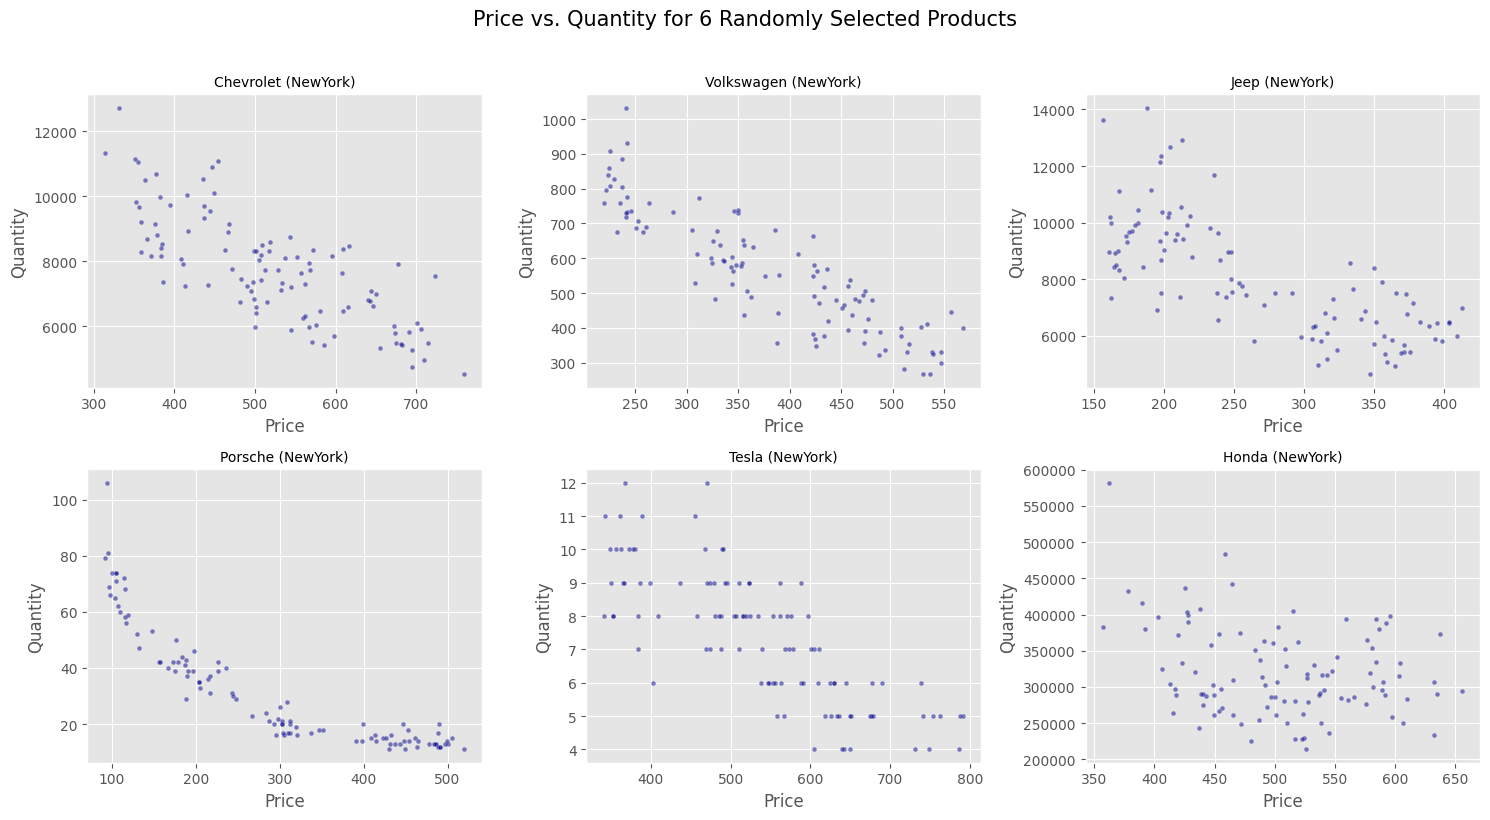

In [61]:
# scatter plot

plt.style.use('ggplot')
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
for ax, product in zip(axes.flatten(), product_list_choice):
  sns.scatterplot(
  data = data.loc[data['product_id'] == product],
  x = 'price',
  y = 'quantity',
  ax = ax,
  alpha = 0.5,
  s=12,
  color = 'darkblue'
  )
  ax.set_xlabel('Price')
  ax.set_ylabel('Quantity')
  ax.set_title(product, fontsize=10)
plt.suptitle('Price vs. Quantity for 6 Randomly Selected Products', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/EDA/price_vs_quantity.png', bbox_inches='tight')

### Own elasticities vs. cross elasticities

In [126]:
# transform product elasticities dataframe to long format for plotting
product_elasticities_long_df = product_elasticities_df.melt(
  id_vars = ['category','state','product','elasticity','intercept'],
  var_name = 'paired_product',
  value_name = 'cross_elasticity'
)
# remove na
product_elasticities_long_df.dropna(axis=0, how='any', inplace=True)

# remove state from the paired product names
words_to_remove = [' (Florida)', ' (NewYork)']
for word in words_to_remove:
    product_elasticities_long_df['paired_product'] = product_elasticities_long_df['paired_product'].str.replace(word, '')
# save dataframe
product_elasticities_long_df.to_csv('data/product_elasticities_long_df.csv')

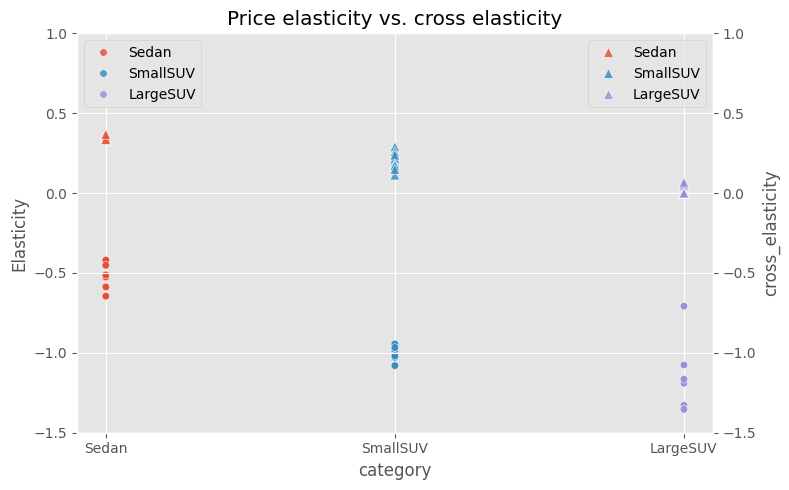

In [168]:
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=product_elasticities_long_df,
    x='category',
    y='elasticity',
    hue='category',
    marker='o',
#    palette='Set1',
    s=30,
    alpha=0.8,
    ax = ax
)
ax.set_ylim(-1.5, 1)
ax.set_ylabel('Elasticity')
ax.legend(loc='upper left')
ax2 = ax.twinx()
sns.scatterplot(
    data=product_elasticities_long_df,
    x='category',
    y='cross_elasticity',
    hue='category',
    marker='^',
#    palette='Set1',
    s=50,
    alpha=0.8,
    ax = ax2
)
ax2.set_ylim(-1.5, 1)
ax2.legend(loc='upper right')
plt.title('Price elasticity vs. cross elasticity')
plt.tight_layout()
plt.savefig('images/EDA/elasticity_crosselasticity.png')

## Model

### No pooling

In [186]:
# create a mapping of product_id to an index for use in the model
product_ids = sorted(data["product_id"].unique())
product_idx_map = {s: i for i, s in enumerate(product_ids)}
obs_product_idx = data["product_id"].map(product_idx_map).values

In [ ]:

# Label the dimension of model variables with the name of the coordinate, which is "product_id" in this case.
coords = {
    'product_id': data['product_id'].unique()
}

with pm.Model(coords=coords) as no_pooling_model:
    # Intercept to baseline demand
    alpha = pm.Normal("alpha", mu=10, sigma=2.0, dims="product_id")
    # Prior of overall elasticity mean across all products
    mu_elasticity = pm.Normal('mu_elasticity', mu=-1, sigma=0.5, dims='product_id')

    # Additive seasonality effect on elasticity mean
    beta_season = pm.Normal('beta_season', mu=0, sigma=0.5) # Can be positive or negative

    # Add standard deviation for the elasticity distributions
    sigma = pm.HalfNormal('sigma', sigma=0.5)

    # Define the expectted log-quantity
    mu = (
        alpha[obs_product_idx] # use index due to tensor indexing requiring integers
        + mu_elasticity[obs_product_idx] * data["log_price"].values
        + beta_season * data["seasonality"].values
        )

    # Define the Bayesian model, connecting model's predictions to the actual data
    pm.Normal("obs", mu=mu, sigma=sigma, observed=data["log_quantity"].values)

    # Run MCMC sampling to approximate the posterior distribution
    trace_no_pooling = pm.sample(
            1000, # sample size
            tune=1000,  # tune-steps
            chains=2, # 2 independent chains
            cores=1,
            random_seed=42, progressbar=True,
            target_accept=0.9, # smaller step
        )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, mu_elasticity, beta_season, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 86 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


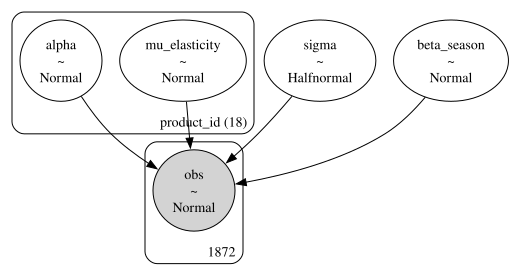

In [205]:
# Diplay PyMC chart for no-pooling model
pm.model_to_graphviz(model=no_pooling_model)

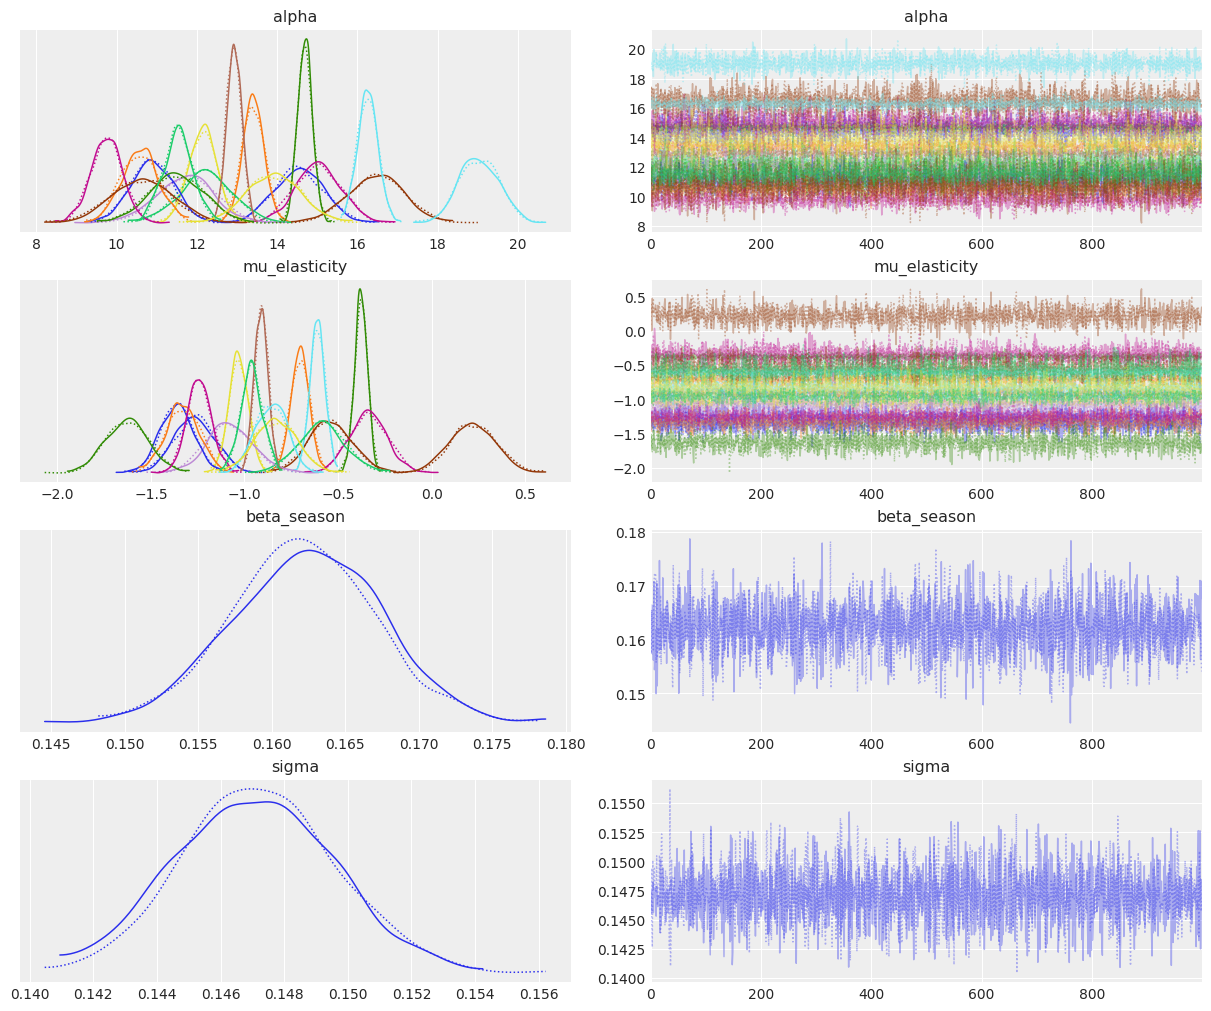

In [206]:
# Generates visual diagnostic subplots for every sampled parameter
az.style.use("arviz-darkgrid")
axes = az.plot_trace(
    data=trace_no_pooling,
    figsize=(12, 10)
)